In [1]:
import random

def coin_toss_simulation(trials):
    """Simulate tossing a coin a number of times and calculate probabilities."""
    heads = 0
    tails = 0
    for _ in range(trials):
        if random.randint(0, 1) == 1:
            heads += 1
        else:
            tails += 1
    prob_heads = heads / trials
    prob_tails = tails / trials
    return heads, tails, prob_heads, prob_tails

def dice_roll_simulation(trials):
    """Simulate rolling two dice a number of times and compute probability of a sum of 7."""
    sum_of_seven = 0
    for _ in range(trials):
        die1 = random.randint(1, 6)
        die2 = random.randint(1, 6)
        if die1 + die2 == 7:
            sum_of_seven += 1
    prob_seven = sum_of_seven / trials
    return sum_of_seven, prob_seven

if __name__ == "__main__":
    trials_coin = 10000
    h, t, ph, pt = coin_toss_simulation(trials_coin)
    print(f"Coin Toss Results ({trials_coin} trials): Heads={h}, Tails={t}, Prob Heads={ph}, Prob Tails={pt}")

    trials_dice = 10000
    s7, p7 = dice_roll_simulation(trials_dice)
    print(f"Dice Roll Results ({trials_dice} trials): Sum of 7 count={s7}, Prob Sum 7={p7}")

Coin Toss Results (10000 trials): Heads=5002, Tails=4998, Prob Heads=0.5002, Prob Tails=0.4998
Dice Roll Results (10000 trials): Sum of 7 count=1712, Prob Sum 7=0.1712


In [3]:
import random

def estimate_six_prob(num_trials):
    """
    Estimates the probability of getting at least one '6' in 10 rolls of a fair die.

    Args:
        num_trials (int): The number of simulation trials to run.

    Returns:
        float: The estimated probability.
    """
    successful_trials = 0
    for _ in range(num_trials):
        # Step a: Simulate rolling a die 10 times
        rolls = [random.randint(1, 6) for _ in range(10)]
        # Step b: Track trials where at least one "6" occurs
        if 6 in rolls:
            successful_trials += 1

    probability_estimate = successful_trials / num_trials
    return probability_estimate

In [5]:
import random

counts = {'Red': 5, 'Green': 7, 'Blue': 8}
total_balls = sum(counts.values())

num_simulations = 1000
balls = list(counts.keys())

# Simulate the sequence of draws
draw_sequence = []
for _ in range(num_simulations):
    r = random.uniform(0, total_balls)
    s = 0
    for ball_color, count in counts.items():
        s += count
        if r <= s:
            draw_sequence.append(ball_color)
            break

blue_then_red_count = 0
previous_blue_count = 0

for i in range(1, num_simulations):
    if draw_sequence[i-1] == 'Blue':
        previous_blue_count += 1
        if draw_sequence[i] == 'Red':
            blue_then_red_count += 1

prob_red_given_blue_sim = blue_then_red_count / previous_blue_count if previous_blue_count > 0 else 0
prob_red_theoretical = counts['Red'] / total_balls
print(f"a. Estimated P(Red | Previous Blue) from simulation: {prob_red_given_blue_sim:.4f} (Theoretical: {prob_red_theoretical:.4f})\n")


total_red_count = draw_sequence.count('Red')
total_blue_count = draw_sequence.count('Blue')

prob_red_sim = total_red_count / num_simulations
prob_blue_sim = total_blue_count / num_simulations

prob_blue_given_red_theoretical = counts['Blue'] / total_balls


red_then_blue_count = 0
for i in range(1, num_simulations):
    if draw_sequence[i-1] == 'Red' and draw_sequence[i] == 'Blue':
        red_then_blue_count += 1

prob_blue_given_red_sim = red_then_blue_count / total_red_count if total_red_count > 0 else 0

print("b. Verifying Bayes' Theorem (P(Blue | Red) \u2248 P(Red | Blue) * P(Blue) / P(Red))")
print(f"   P(Red) (Sim): {prob_red_sim:.4f}, P(Blue) (Sim): {prob_blue_sim:.4f}")
print(f"   P(Blue | Red) (Sim): {prob_blue_given_red_sim:.4f} (Theoretical: {prob_blue_given_red_theoretical:.4f})")


bayes_calc_sim = prob_red_given_blue_sim * prob_blue_sim / prob_red_sim if prob_red_sim > 0 else 0 # Corrected calculation for Bayes' Theorem
print(f"   Bayes Calculation from Simulation: {bayes_calc_sim:.4f}")


a. Estimated P(Red | Previous Blue) from simulation: 0.2675 (Theoretical: 0.2500)

b. Verifying Bayes' Theorem (P(Blue | Red) ≈ P(Red | Blue) * P(Blue) / P(Red))
   P(Red) (Sim): 0.2680, P(Blue) (Sim): 0.3850
   P(Blue | Red) (Sim): 0.2948 (Theoretical: 0.4000)
   Bayes Calculation from Simulation: 0.3843


In [6]:
import numpy as np

values = [1, 2, 3]
probabilities = [0.25, 0.35, 0.4]
size = 1000

sample = np.random.choice(values, size=size, p=probabilities)

mean = np.mean(sample)
variance = np.var(sample)
std_dev = np.std(sample)

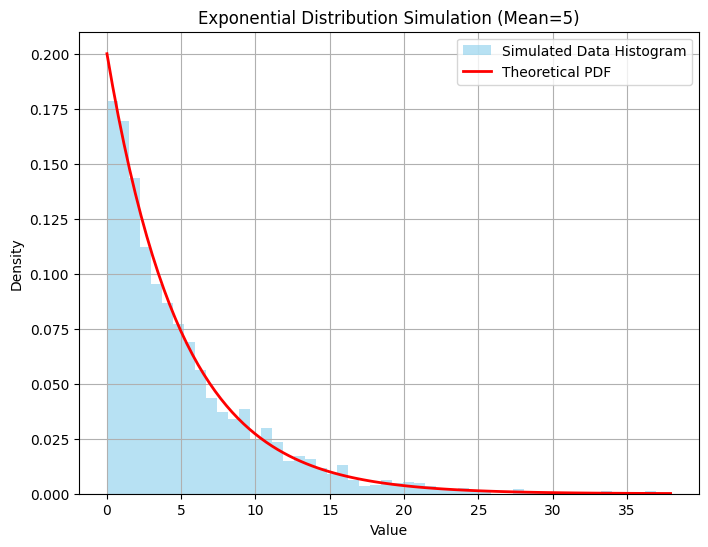

In [7]:
import numpy as np
import matplotlib.pyplot as plt

mean_val = 5
num_samples = 2000
scale_val = mean_val  # scale is the inverse of the rate parameter
lambda_val = 1 / mean_val

samples = np.random.exponential(scale=scale_val, size=num_samples)

x = np.linspace(0, samples.max() + 1, 100)
pdf_values = lambda_val * np.exp(-lambda_val * x)


plt.figure(figsize=(8, 6))
plt.hist(samples, bins=50, density=True, alpha=0.6, color='skyblue', label='Simulated Data Histogram')
# Plot the theoretical PDF as a line
plt.plot(x, pdf_values, 'r-', lw=2, label='Theoretical PDF')

plt.title('Exponential Distribution Simulation (Mean=5)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-488265337.py:12: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

...

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

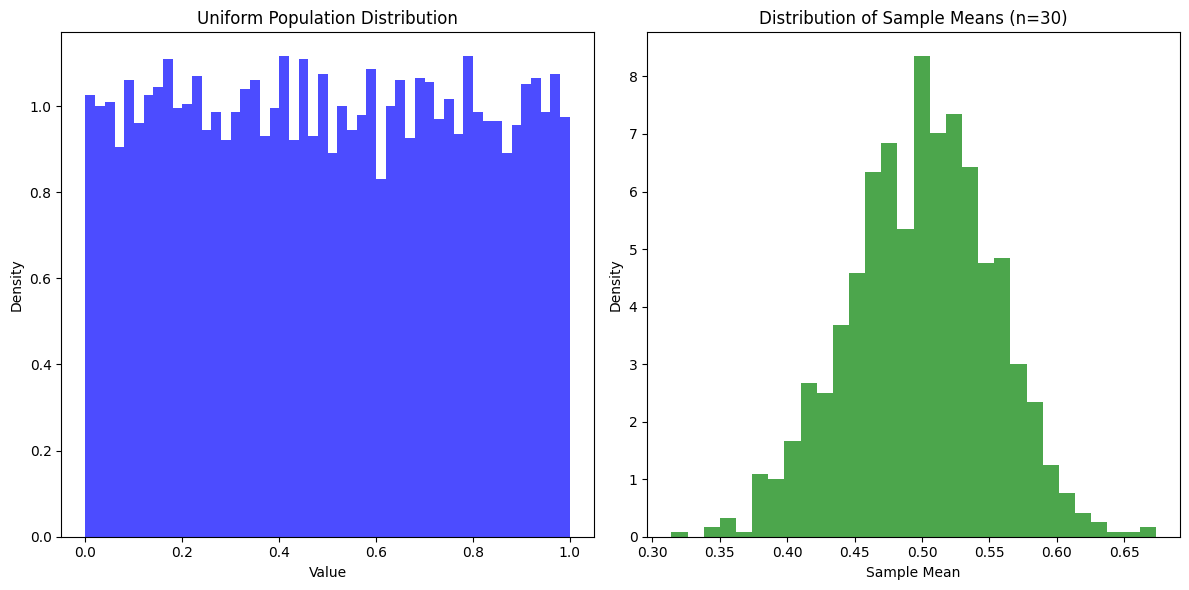

In [8]:
import numpy as np
import matplotlib.pyplot as plt
n_population = 10000
population = np.random.uniform(low=0, high=1, size=n_population)
n_samples = 1000
sample_size = 30
sample_means = []

for _ in range(n_samples):
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))
    plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(population, bins=50, density=True, color='blue', alpha=0.7)
plt.title('Uniform Population Distribution')
plt.xlabel('Value')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
plt.hist(sample_means, bins=30, density=True, color='green', alpha=0.7)
plt.title('Distribution of Sample Means (n=30)')
plt.xlabel('Sample Mean')
plt.ylabel('Density')

plt.tight_layout()
plt.show()